In [1]:
import sys

!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install librosa
!{sys.executable} -m pip install ruptures
!{sys.executable} -m pip install matplotlib

# Imports
import librosa as lb
import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

  Using cached matplotlib-3.10.6-cp310-cp310-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp310-cp310-macosx_10_9_universal2.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.6-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.1-cp310-cp310-macosx_10_9_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
Using cached pillow-11.3.0-cp310-cp310-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.2.5-p

In [2]:
# Constants
song_file_path = "/Users/shivamenta/Desktop/training_data copy/KETTAMA - It Gets Better - Forever Mix.mp3"
FREQUENCY_BUCKETS = [(0, 200), (201, 600), (601, 3000), (3001, 7000), (7001, 22000)]

STFT Change Point Detection

In [13]:
y, sr = lb.load(song_file_path, sr=None)
stft_result = lb.stft(y, n_fft=2048, hop_length=512)
magnitude = np.abs(stft_result)
freqs = lb.fft_frequencies(sr=sr)

freq_bucket_to_signal = [[] for _ in range(len(FREQUENCY_BUCKETS))]
num_time_slices = stft_result.shape[1]

for t in range(num_time_slices):
    for i, (lower, upper) in enumerate(FREQUENCY_BUCKETS):
        freq_indices = np.where((freqs >= lower) & (freqs <= upper))[0]
        bucket_intensity = np.sum(magnitude[freq_indices, t])
        freq_bucket_to_signal[i].append(bucket_intensity)


# Smooth Out Signal
def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w


for idx, bucket in enumerate(freq_bucket_to_signal):
    np_arr = np.array(bucket)
    freq_bucket_to_signal[idx] = moving_average(np_arr, 200)

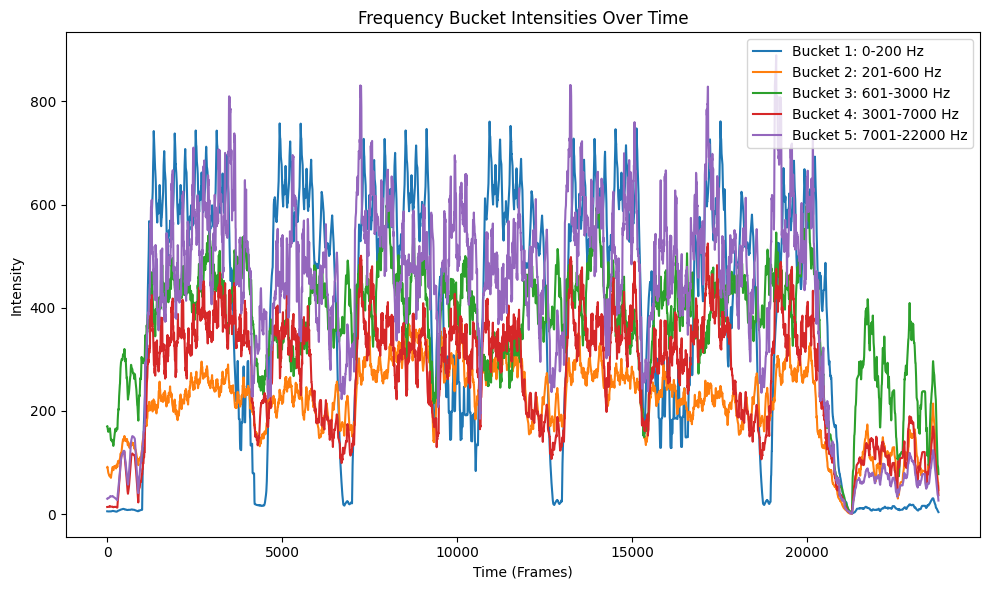

In [14]:
def plot_frequency_buckets(predicted_change_points=[], actual_change_points=[]):
    plt.figure(figsize=(10, 6))

    # Plot each frequency bucket's intensity over time
    for i, bucket in enumerate(freq_bucket_to_signal):
        plt.plot(
            bucket,
            label=f"Bucket {i+1}: {FREQUENCY_BUCKETS[i][0]}-{FREQUENCY_BUCKETS[i][1]} Hz",
        )

    # Label the axes and add a title
    plt.xlabel("Time (Frames)")
    plt.ylabel("Intensity")
    plt.title("Frequency Bucket Intensities Over Time")

    for cp in predicted_change_points:
        plt.axvline(
            x=cp,
            color="red",
            linestyle="--",
            label="Predicted Change Point" if cp == predicted_change_points[0] else "",
        )
    for cp in actual_change_points:
        plt.axvline(
            x=cp,
            color="blue",
            linestyle="--",
            label="Actual Change Point" if cp == predicted_change_points[0] else "",
        )

    # Add a legend to distinguish the different frequency buckets
    plt.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()


# Plot the results
plot_frequency_buckets()

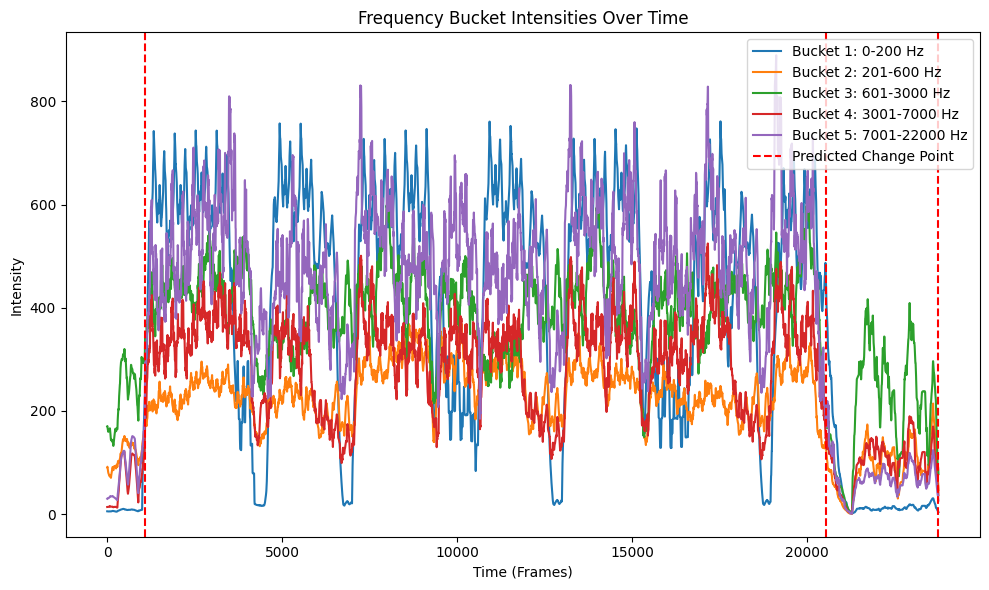

[np.int32(1083), np.int32(20550), 23761]


In [15]:
# 200 100000000
mat = np.array(freq_bucket_to_signal).T
model = rpt.KernelCPD(kernel="linear", min_size=157).fit(mat)
estimated_change_points = model.predict(pen=100000000)

plot_frequency_buckets(estimated_change_points, [])
print(estimated_change_points)

Vocal Track Separation Demo (Spleeter)


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Loading Demucs model...
Loading audio from: /Users/shivamenta/dj/playlists/Dubstep/PEEKABOO - Yeke Yeke.mp3
Separating vocals (this may take 1-3 minutes)...
✓ Vocal separation complete!
Analyzing vocal track...

Vocal Activity Segments:
Segment  1:   0.39s -   1.93s (duration:  1.53s)
Segment  2:   2.11s -   2.30s (duration:  0.19s)
Segment  3:   2.32s -   5.43s (duration:  3.11s)
Segment  4:   5.53s -   8.89s (duration:  3.37s)
Segment  5:   8.94s -  10.84s (duration:  1.90s)
Segment  6:  10.87s -  15.65s (duration:  4.78s)
Segment  7:  15.81s -  19

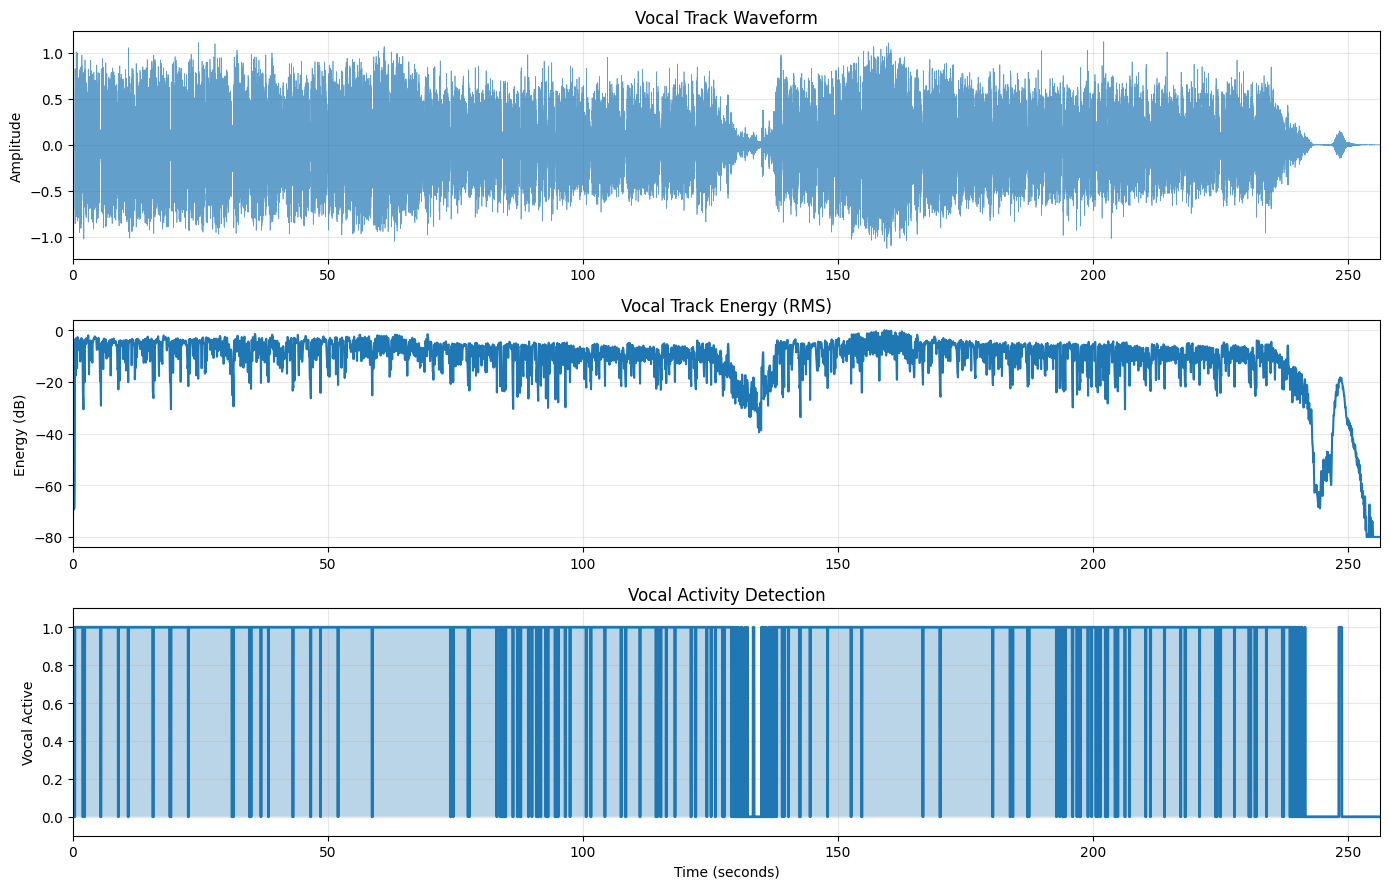

In [4]:
import sys

!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install librosa
!{sys.executable} -m pip install ruptures
!{sys.executable} -m pip install matplotlib

# Imports
import librosa as lb
import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import librosa
import torch
import torchaudio
import matplotlib.pyplot as plt
from pathlib import Path
from demucs.pretrained import get_model
from demucs.apply import apply_model

song_file_mp3 = "/Users/shivamenta/dj/playlists/Dubstep/PEEKABOO - Yeke Yeke.mp3"
import numpy as np
import librosa
import torch
import torchaudio
import matplotlib.pyplot as plt
from pathlib import Path
from demucs.pretrained import get_model
from demucs.apply import apply_model

def separate_vocals(audio_path):
    """
    Separate vocals from audio using Demucs Python API.
    
    Args:
        audio_path: Path to audio file
    
    Returns:
        vocals: Tensor of separated vocal track
        sr: Sample rate
    """
    print("Loading Demucs model...")
    # Load pretrained model (htdemucs is the default, best quality)
    model = get_model('htdemucs')
    model.eval()
    
    # Load audio file
    print(f"Loading audio from: {audio_path}")
    waveform, sr = torchaudio.load(audio_path)
    
    # Demucs expects stereo input, convert mono to stereo if needed
    if waveform.shape[0] == 1:
        waveform = waveform.repeat(2, 1)
    
    # Add batch dimension
    waveform = waveform.unsqueeze(0)
    
    print("Separating vocals (this may take 1-3 minutes)...")
    # Apply model
    with torch.no_grad():
        sources = apply_model(model, waveform, device='cpu', shifts=1, split=True)
    
    # Extract vocals (index 3 for htdemucs: drums=0, bass=1, other=2, vocals=3)
    vocals = sources[0, 3]  # Shape: [channels, samples]
    
    print("✓ Vocal separation complete!")
    return vocals, sr


def detect_vocal_activity(mp3_path, threshold_db=-40, frame_length=2048, hop_length=512):
    """
    Detect when vocals are active in an MP3 file using Demucs Python API.
    
    Args:
        mp3_path: Path to the MP3 file
        threshold_db: Energy threshold in dB (lower = more sensitive)
        frame_length: Frame size for analysis
        hop_length: Hop size between frames
    
    Returns:
        Dictionary with timestamps and vocal activity boolean array
    """
    
    # Step 1: Separate vocals using Demucs Python API
    vocals_tensor, sr = separate_vocals(mp3_path)
    
    # Step 2: Convert to numpy and mono for analysis
    print("Analyzing vocal track...")
    # Average stereo channels to mono
    vocals_numpy = vocals_tensor.mean(dim=0).numpy()
    
    # Resample to 22050 Hz for consistency with librosa
    vocals_numpy = librosa.resample(vocals_numpy, orig_sr=sr, target_sr=22050)
    sr = 22050
    
    # Step 3: Calculate frame-by-frame energy (RMS)
    rms = librosa.feature.rms(y=vocals_numpy, frame_length=frame_length, hop_length=hop_length)[0]
    
    # Convert to dB
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)
    
    # Step 4: Threshold to detect activity
    is_vocal_active = rms_db > threshold_db
    
    # Step 5: Convert frame indices to timestamps
    times = librosa.frames_to_time(np.arange(len(rms_db)), sr=sr, hop_length=hop_length)
    
    # Step 6: Create segments of continuous vocal activity
    segments = []
    in_segment = False
    start_time = 0
    
    for i, active in enumerate(is_vocal_active):
        if active and not in_segment:
            start_time = times[i]
            in_segment = True
        elif not active and in_segment:
            segments.append((start_time, times[i]))
            in_segment = False
    
    # Close last segment if needed
    if in_segment:
        segments.append((start_time, times[-1]))
    
    return {
        'times': times,
        'is_active': is_vocal_active,
        'rms_db': rms_db,
        'segments': segments,
        'sample_rate': sr,
        'vocals_audio': vocals_numpy
    }


def plot_vocal_activity(result):
    """Visualize the vocal activity detection with waveform."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 9))
    
    # Create time array for waveform
    waveform_times = np.linspace(0, len(result['vocals_audio']) / result['sample_rate'], 
                                  len(result['vocals_audio']))
    
    # Plot 1: Waveform
    axes[0].plot(waveform_times, result['vocals_audio'], linewidth=0.5, alpha=0.7)
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Vocal Track Waveform')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, waveform_times[-1])
    
    # Plot 2: RMS energy
    axes[1].plot(result['times'], result['rms_db'])
    axes[1].set_ylabel('Energy (dB)')
    axes[1].set_title('Vocal Track Energy (RMS)')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, result['times'][-1])
    
    # Plot 3: Vocal activity with shaded regions
    axes[2].fill_between(result['times'], 0, result['is_active'].astype(int), 
                          alpha=0.3, label='Vocal Active')
    axes[2].plot(result['times'], result['is_active'].astype(int), linewidth=2)
    axes[2].set_ylabel('Vocal Active')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].set_title('Vocal Activity Detection')
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim(0, result['times'][-1])
    
    plt.tight_layout()
    plt.savefig('vocal_activity.png', dpi=150, bbox_inches='tight')
    print("Visualization saved as 'vocal_activity.png'")


def export_segments_to_file(segments, output_file='vocal_segments.txt'):
    """Export vocal segments to a text file."""
    with open(output_file, 'w') as f:
        f.write("Vocal Activity Segments\n")
        f.write("=" * 40 + "\n\n")
        for i, (start, end) in enumerate(segments, 1):
            duration = end - start
            f.write(f"Segment {i}: {start:6.2f}s - {end:6.2f}s (duration: {duration:.2f}s)\n")
    print(f"Segments exported to: {output_file}")


def save_vocal_track(vocals_audio, sr, output_path='separated_vocals.wav'):
    """Save the separated vocal track to a file."""
    import soundfile as sf
    sf.write(output_path, vocals_audio, sr)
    print(f"Vocal track saved to: {output_path}")


# Example usage
if __name__ == "__main__":
    # Analyze an MP3 file
    result = detect_vocal_activity(song_file_mp3, threshold_db=-20)
    
    # Print vocal segments
    print("\n" + "="*50)
    print("Vocal Activity Segments:")
    print("="*50)
    for i, (start, end) in enumerate(result['segments'], 1):
        duration = end - start
        print(f"Segment {i:2d}: {start:6.2f}s - {end:6.2f}s (duration: {duration:5.2f}s)")
    
    # Calculate statistics
    total_time = result['times'][-1]
    vocal_time = np.sum(result['is_active']) * (result['times'][1] - result['times'][0])
    vocal_percentage = (vocal_time / total_time) * 100
    
    print("\n" + "="*50)
    print("Statistics:")
    print("="*50)
    print(f"Total song duration: {total_time:.2f}s")
    print(f"Vocal active time: {vocal_time:.2f}s ({vocal_percentage:.1f}%)")
    print(f"Number of vocal segments: {len(result['segments'])}")
    
    # Save separated vocal track
    save_vocal_track(result['vocals_audio'], result['sample_rate'])
    
    # Export segments to file
    export_segments_to_file(result['segments'])
    
    # Create visualization
    plot_vocal_activity(result)
    
    print("\n✓ Analysis complete!")